In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

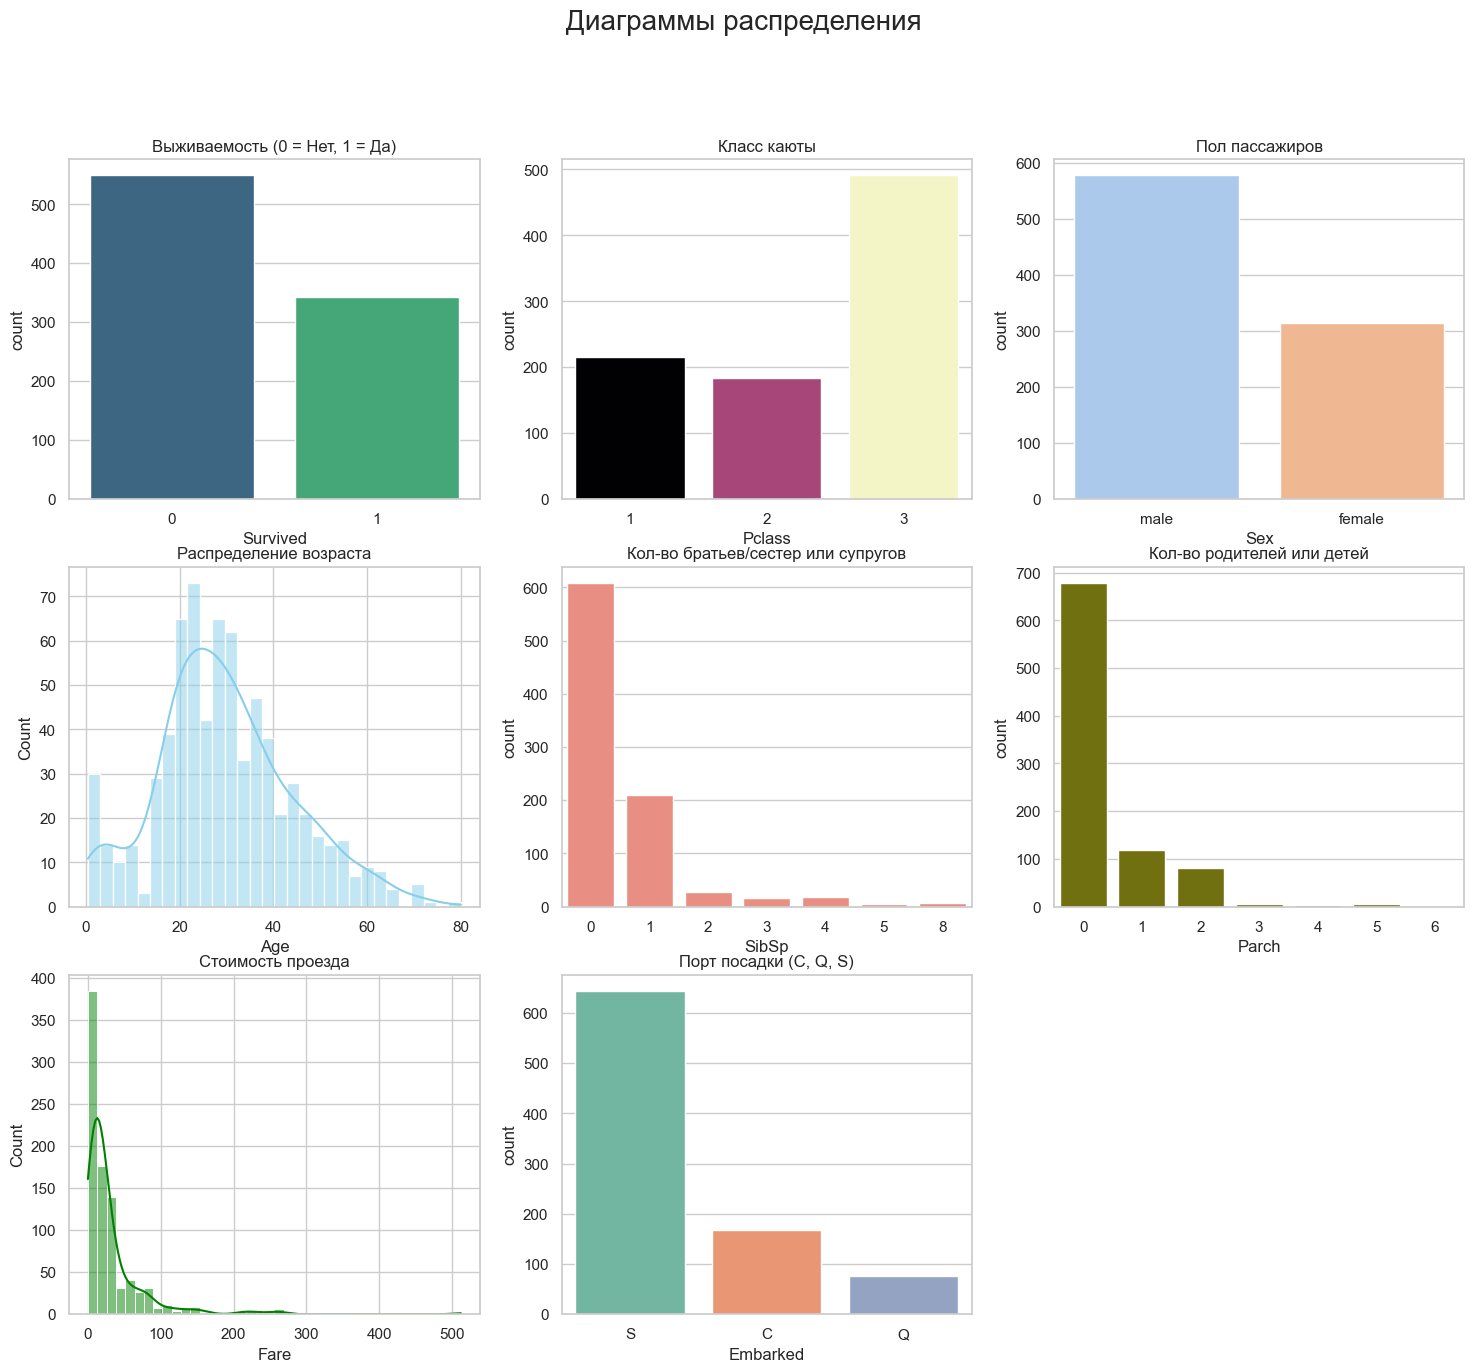

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('titanic.csv')

# Настройка общей сетки графиков с помощью Matplotlib
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle('Диаграммы распределения', fontsize=20)

# 1. Survived (Целевой признак)
sns.countplot(x='Survived', hue='Survived', data=df, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('Выживаемость (0 = Нет, 1 = Да)')

# 2. Pclass (Класс билета)
sns.countplot(x='Pclass', hue='Pclass', data=df, ax=axes[0, 1], palette='magma', legend=False)
axes[0, 1].set_title('Класс каюты')

# 3. Sex (Пол)
sns.countplot(x='Sex', hue='Sex', data=df, ax=axes[0, 2], palette='pastel', legend=False)
axes[0, 2].set_title('Пол пассажиров')

# 4. Age (Возраст)
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Распределение возраста')

# 5. SibSp (Семья: братья/сестры, супруги)
sns.countplot(x='SibSp', data=df, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Кол-во братьев/сестер или супругов')

# 6. Parch (Семья: родители/дети)
sns.countplot(x='Parch', data=df, ax=axes[1, 2], color='olive')
axes[1, 2].set_title('Кол-во родителей или детей')

# 7. Fare (Стоимость билета)
sns.histplot(df['Fare'], bins=40, kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('Стоимость проезда')

# 8. Embarked (Порт посадки)
sns.countplot(x='Embarked', hue='Embarked', data=df, ax=axes[2, 1], palette='Set2', legend=False)
axes[2, 1].set_title('Порт посадки (C, Q, S)')

# Удаляем пустой нижний правый график, если он не нужен
fig.delaxes(axes[2, 2])

# Указываем путь и настройки качества
plt.savefig('titanic_plots.png', dpi=300, bbox_inches='tight')

plt.show()

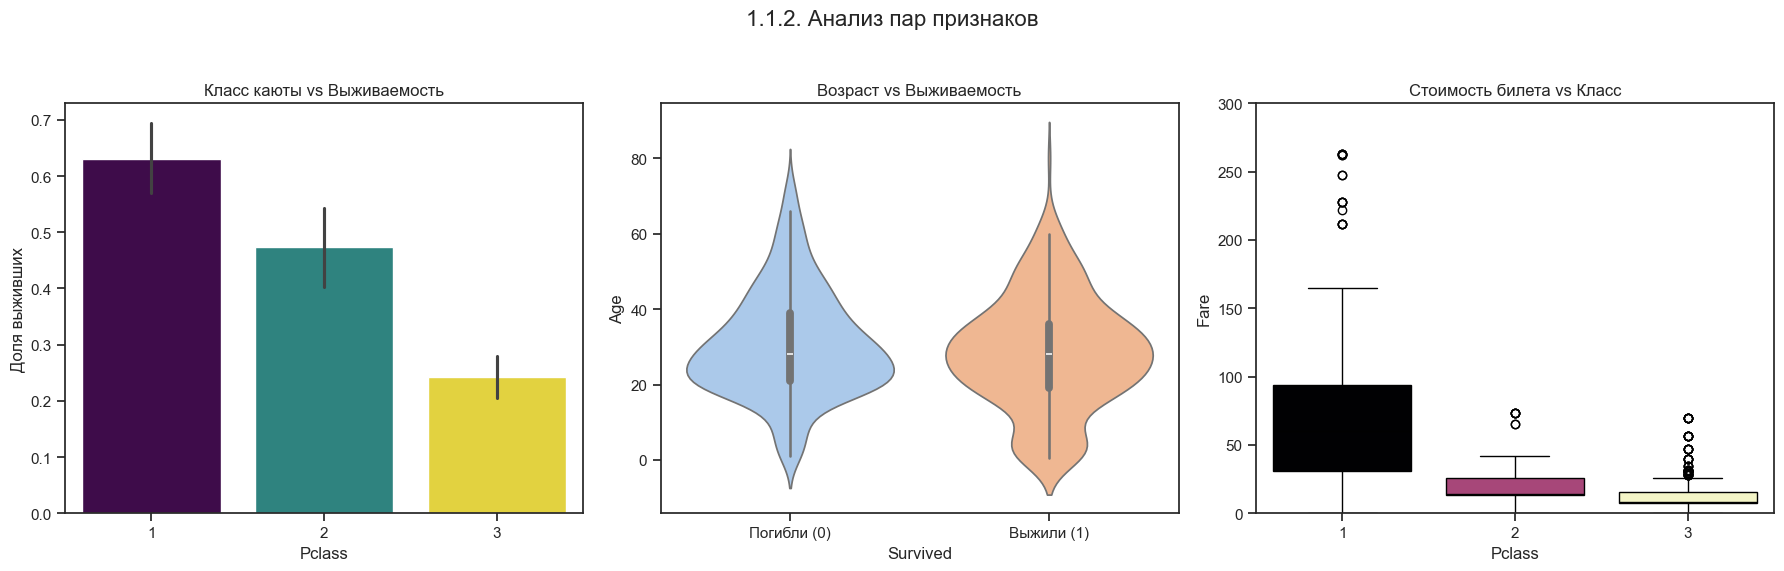

In [11]:
df = pd.read_csv('titanic.csv')
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('1.1.2. Анализ пар признаков', fontsize=16)

# 1. Pclass vs Survived (Влияние класса на выживаемость)
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Класс каюты vs Выживаемость')
axes[0].set_ylabel('Доля выживших')
if axes[0].get_legend(): axes[0].get_legend().remove()

# 2. Age vs Survived (Распределение возраста среди выживших и погибших)
sns.violinplot(x='Survived', y='Age', hue='Survived', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Возраст vs Выживаемость')
# ИСПРАВЛЕНИЕ ОШИБКИ: сначала устанавливаем позиции тиков, потом подписи
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Погибли (0)', 'Выжили (1)'])
if axes[1].get_legend(): axes[1].get_legend().remove()

# 3. Fare vs Pclass (Связь стоимости билета и класса)
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Стоимость билета vs Класс')
axes[2].set_ylim(0, 300) # Ограничение для наглядности (убираем экстремальные выбросы)
if axes[2].get_legend(): axes[2].get_legend().remove()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# СОХРАНЕНИЕ: вызываем до plt.show()
plt.savefig('titanic_pairs_analysis.png', dpi=300, bbox_inches='tight')

# Показ графика
plt.show()

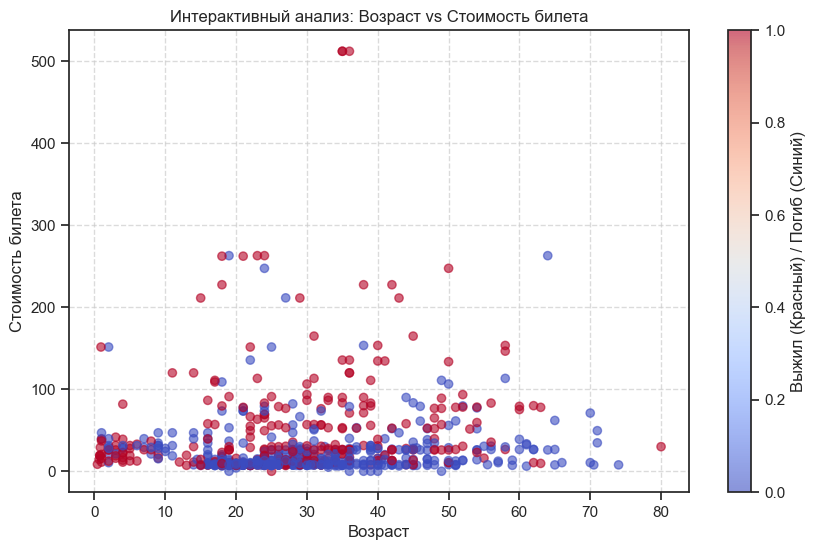

In [12]:
df = pd.read_csv('titanic.csv')

# Создаем интерактивную диаграмму рассеяния (Возраст vs Стоимость билета)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Age'], df['Fare'], c=df['Survived'], cmap='coolwarm', alpha=0.6)

plt.title('Интерактивный анализ: Возраст vs Стоимость билета')
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.colorbar(scatter, label='Выжил (Красный) / Погиб (Синий)')
plt.grid(True, linestyle='--', alpha=0.7)

# СОХРАНЕНИЕ: вызываем до plt.show()
plt.savefig('titanic_pairs_analysis.png', dpi=300, bbox_inches='tight')

plt.show()